In [8]:
#1
from datasets import load_dataset
import polars as pl

columns = [
    "inn",
    "ogrn",
    "line_1600",
    "line_1700",
    "line_1300",
    "line_1400",
    "line_2110",
    "line_2400",
    "line_1230",
    "line_1150",
    "line_1200",
    "line_1250",
    "line_1510",
    "line_1520",
    "line_2100",
    "line_2200",
    "line_2300",
    "line_1370",
    "eligible",
    "financial",
]

# Загружаем только первые 1000 строк
ds = load_dataset(
    "irlspbru/RFSD",
    data_files="RFSD/year=2023/*.parquet",
    split="train[:1000]"
)

# Оставляем только нужные колонки
ds = ds.select_columns(columns)
RFSD_2023 = pl.from_arrow(ds.data.table)

In [2]:
#1
# Размерность датасета (строки, колонки)
print(f"Размер датасета: {RFSD_2023.shape}")
print(f"Количество строк: {RFSD_2023.shape[0]}, колонок: {RFSD_2023.shape[1]}")
print()

# Типы данных колонок
print("Типы данных:")
print(RFSD_2023.schema)
print()

# Описательная статистика (count, mean, std, min, max, median и др.)
print("Описательная статистика:")
print(RFSD_2023.describe())
print()

# Количество пропущенных значений по каждой колонке
print("Пропущенные значения (null count):")
print(RFSD_2023.null_count())
print()

# Первые 5 строк (по умолчанию)
print("Первые строки датасета:")
print(RFSD_2023.head())

Размер датасета: (1000, 20)
Количество строк: 1000, колонок: 20

Типы данных:
Schema({'inn': String, 'ogrn': String, 'line_1600': Float64, 'line_1700': Float64, 'line_1300': Float64, 'line_1400': Float64, 'line_2110': Float64, 'line_2400': Float64, 'line_1230': Float64, 'line_1150': Float64, 'line_1200': Float64, 'line_1250': Float64, 'line_1510': Float64, 'line_1520': Float64, 'line_2100': Float64, 'line_2200': Float64, 'line_2300': Float64, 'line_1370': Float64, 'eligible': Float64, 'financial': Float64})

Описательная статистика:
shape: (9, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ statistic ┆ inn       ┆ ogrn      ┆ line_1600 ┆ … ┆ line_2300 ┆ line_1370 ┆ eligible ┆ financial │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ str       ┆ str       ┆ str       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═════

Базовая статистика по колонкам:
shape: (9, 4)
┌────────────┬──────────────┬──────────────┬──────────────┐
│ statistic  ┆ line_2100    ┆ line_2200    ┆ line_2400    │
│ ---        ┆ ---          ┆ ---          ┆ ---          │
│ str        ┆ f64          ┆ f64          ┆ f64          │
╞════════════╪══════════════╪══════════════╪══════════════╡
│ count      ┆ 274.0        ┆ 487.0        ┆ 549.0        │
│ null_count ┆ 726.0        ┆ 513.0        ┆ 451.0        │
│ mean       ┆ 16933.032847 ┆ 5776.034908  ┆ 3329.531876  │
│ std        ┆ 73023.603616 ┆ 29622.368328 ┆ 23936.837846 │
│ min        ┆ -39311.0     ┆ -90543.0     ┆ -141739.0    │
│ 25%        ┆ 3.0          ┆ -36.0        ┆ -14.0        │
│ 50%        ┆ 615.0        ┆ 131.0        ┆ 33.0         │
│ 75%        ┆ 4337.0       ┆ 1277.0       ┆ 750.0        │
│ max        ┆ 834036.0     ┆ 341158.0     ┆ 286671.0     │
└────────────┴──────────────┴──────────────┴──────────────┘

Расширенная статистика:

line_2100:
  Мин: -39311.0
 

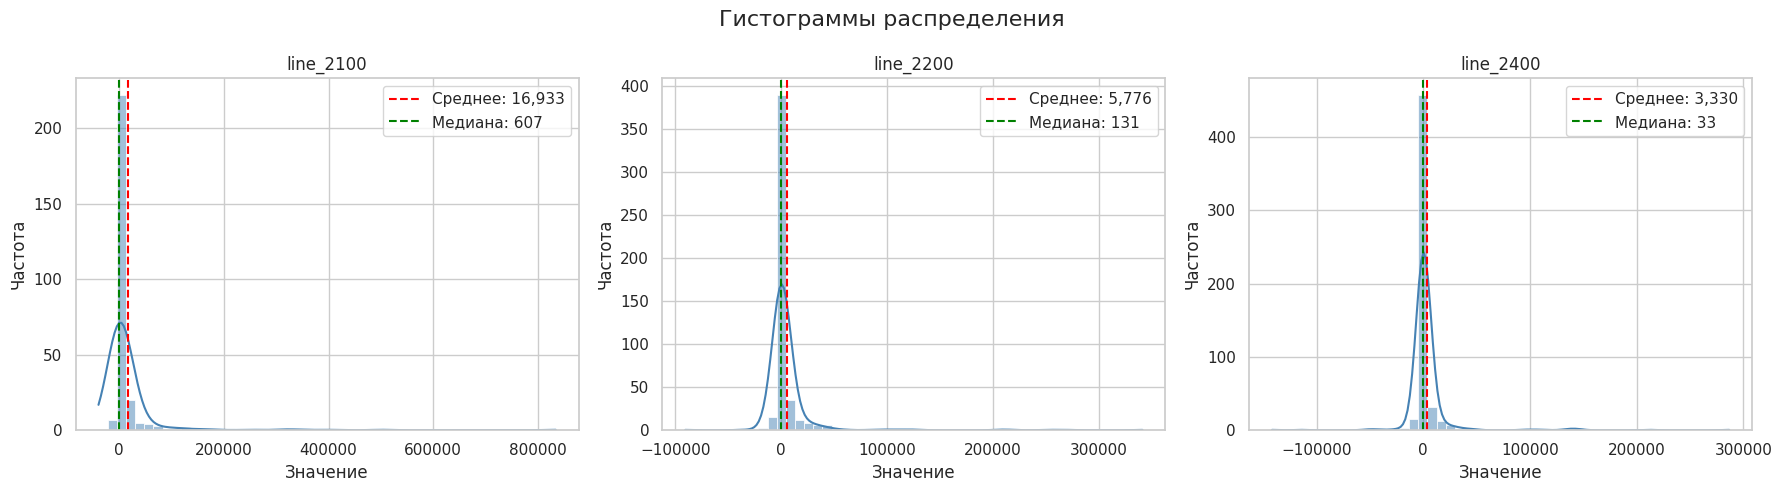

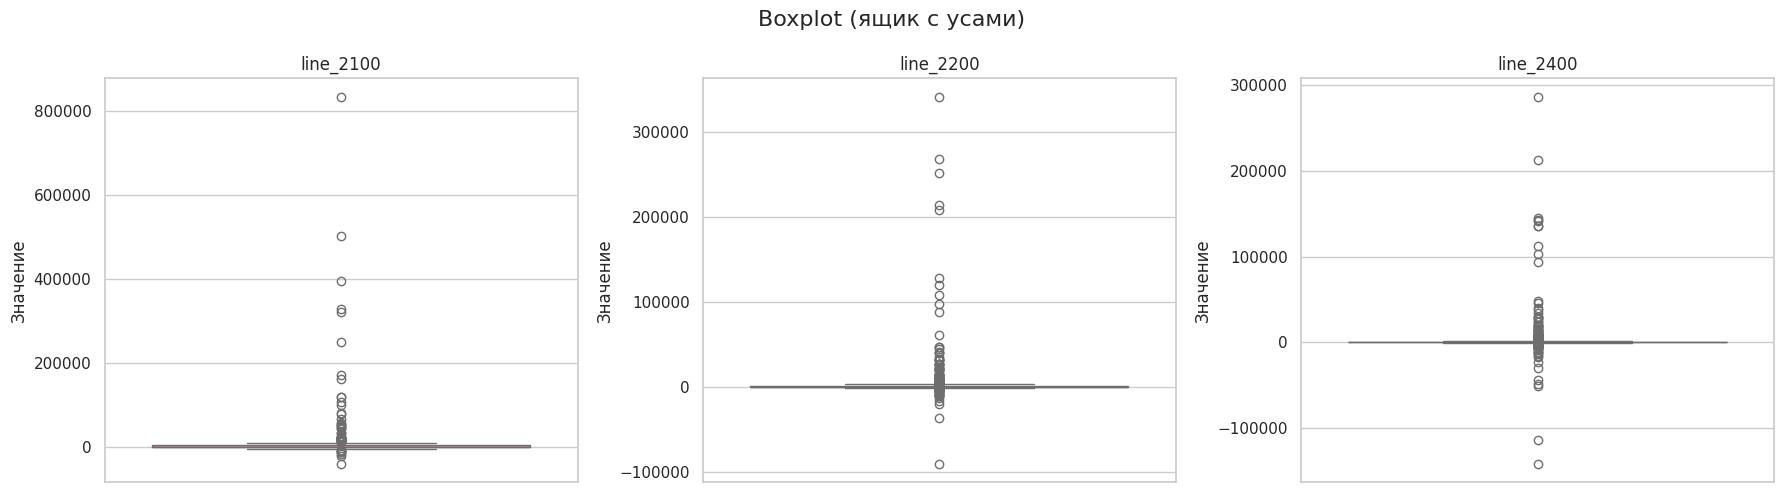


Анализ выбросов (метод IQR):

line_2100:
  Границы нормальных значений: [-6,498.00, 10,838.00]
  Количество выбросов: 56 (20.44%)
  Топ-10 выбросов (строки):
shape: (10, 20)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ inn       ┆ ogrn      ┆ line_1600 ┆ line_1700 ┆ … ┆ line_2300 ┆ line_1370 ┆ eligible ┆ financial │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ str       ┆ str       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ 010100077 ┆ 102010050 ┆ 1.759275e ┆ 1.759275e ┆ … ┆ 194557.0  ┆ 1.023864e ┆ 1.0      ┆ 0.0       │
│ 6         ┆ 7063      ┆ 6         ┆ 6         ┆   ┆           ┆ 6         ┆          ┆           │
│ 010000015 ┆ 121010000 ┆ 5.746161e ┆ 5.746161e ┆ … ┆ -142357.0 ┆ -95316.0  ┆ 1.0      ┆ 0.0       │
│ 6         ┆ 243

In [11]:
#2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
cols = ["line_2100", "line_2200", "line_2400"]

# ------------------- 1. Базовая статистика -------------------
print("=" * 60)
print("Базовая статистика по колонкам:")
print("=" * 60)

stats = RFSD_2023.select(cols).describe()
print(stats)

# Дополнительная статистика: медиана, процентили, пропуски, нули
print("\n" + "=" * 60)
print("Расширенная статистика:")
print("=" * 60)
for col in cols:
    series = RFSD_2023[col]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    n_null = series.null_count()
    n_zero = (series == 0).sum()
    n_negative = (series < 0).sum()

    print(f"\n{col}:")
    print(f"  Мин: {series.min()}")
    print(f"  Макс: {series.max()}")
    print(f"  Медиана: {series.quantile(0.5)}")
    print(f"  Q1: {q1}, Q3: {q3}, IQR: {iqr}")
    print(f"  Пропуски: {n_null}")
    print(f"  Нулевые значения: {n_zero}")
    print(f"  Отрицательные значения: {n_negative}")

# ------------------- 2. Гистограммы -------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Гистограммы распределения", fontsize=16)

for i, col in enumerate(cols):
    # Убираем пропуски для построения
    data = RFSD_2023[col].drop_nulls().to_numpy()

    sns.histplot(data, ax=axes[i], kde=True, bins=50, color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")

    # Добавляем вертикальные линии: среднее и медиана
    mean_val = np.mean(data)
    median_val = np.median(data)
    axes[i].axvline(mean_val, color="red", linestyle="--", label=f"Среднее: {mean_val:,.0f}")
    axes[i].axvline(median_val, color="green", linestyle="--", label=f"Медиана: {median_val:,.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

# ------------------- 3. Boxplot (для выбросов) -------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Boxplot (ящик с усами)", fontsize=16)

for i, col in enumerate(cols):
    data = RFSD_2023[col].drop_nulls().to_numpy()
    sns.boxplot(y=data, ax=axes[i], color="lightcoral")
    axes[i].set_title(col)
    axes[i].set_ylabel("Значение")

plt.tight_layout()
plt.show()

# ------------------- 4. Поиск выбросов по методу IQR -------------------
print("\n" + "=" * 60)
print("Анализ выбросов (метод IQR):")
print("=" * 60)

for col in cols:
    series = RFSD_2023[col].drop_nulls()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Считаем количество выбросов через Series
    outliers_series = series.filter((series < lower_bound) | (series > upper_bound))
    outlier_pct = len(outliers_series) / len(series) * 100

    print(f"\n{col}:")
    print(f"  Границы нормальных значений: [{lower_bound:,.2f}, {upper_bound:,.2f}]")
    print(f"  Количество выбросов: {len(outliers_series)} ({outlier_pct:.2f}%)")

    if len(outliers_series) > 0:
        # Фильтруем ВЕСЬ DataFrame, чтобы видеть строки целиком
        outlier_df = RFSD_2023.filter(
            (pl.col(col) < lower_bound) | (pl.col(col) > upper_bound)
        )

        # Сортируем DataFrame по нужной колонке
        top_outliers_df = outlier_df.sort(by=col, descending=True).head(10)

        print(f"  Топ-10 выбросов (строки):")
        print(top_outliers_df)

Анализируем 18 числовых колонок
Осталось строк после удаления пропусков: 45

Матрица корреляции (первые 5 строк и столбцов):
shape: (5, 18)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ line_1600 ┆ line_1700 ┆ line_1300 ┆ line_1400 ┆ … ┆ line_2300 ┆ line_1370 ┆ eligible ┆ financial │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ 1.0       ┆ 1.0       ┆ 0.414465  ┆ 0.903594  ┆ … ┆ 0.066798  ┆ 0.306976  ┆ NaN      ┆ NaN       │
│ 1.0       ┆ 1.0       ┆ 0.414465  ┆ 0.903594  ┆ … ┆ 0.066798  ┆ 0.306976  ┆ NaN      ┆ NaN       │
│ 0.414465  ┆ 0.414465  ┆ 1.0       ┆ 0.018208  ┆ … ┆ 0.671417  ┆ 0.85573   ┆ NaN      ┆ NaN       │
│ 0.903594  ┆ 0.903594  ┆ 0.018208  ┆ 1.0       ┆ … 

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


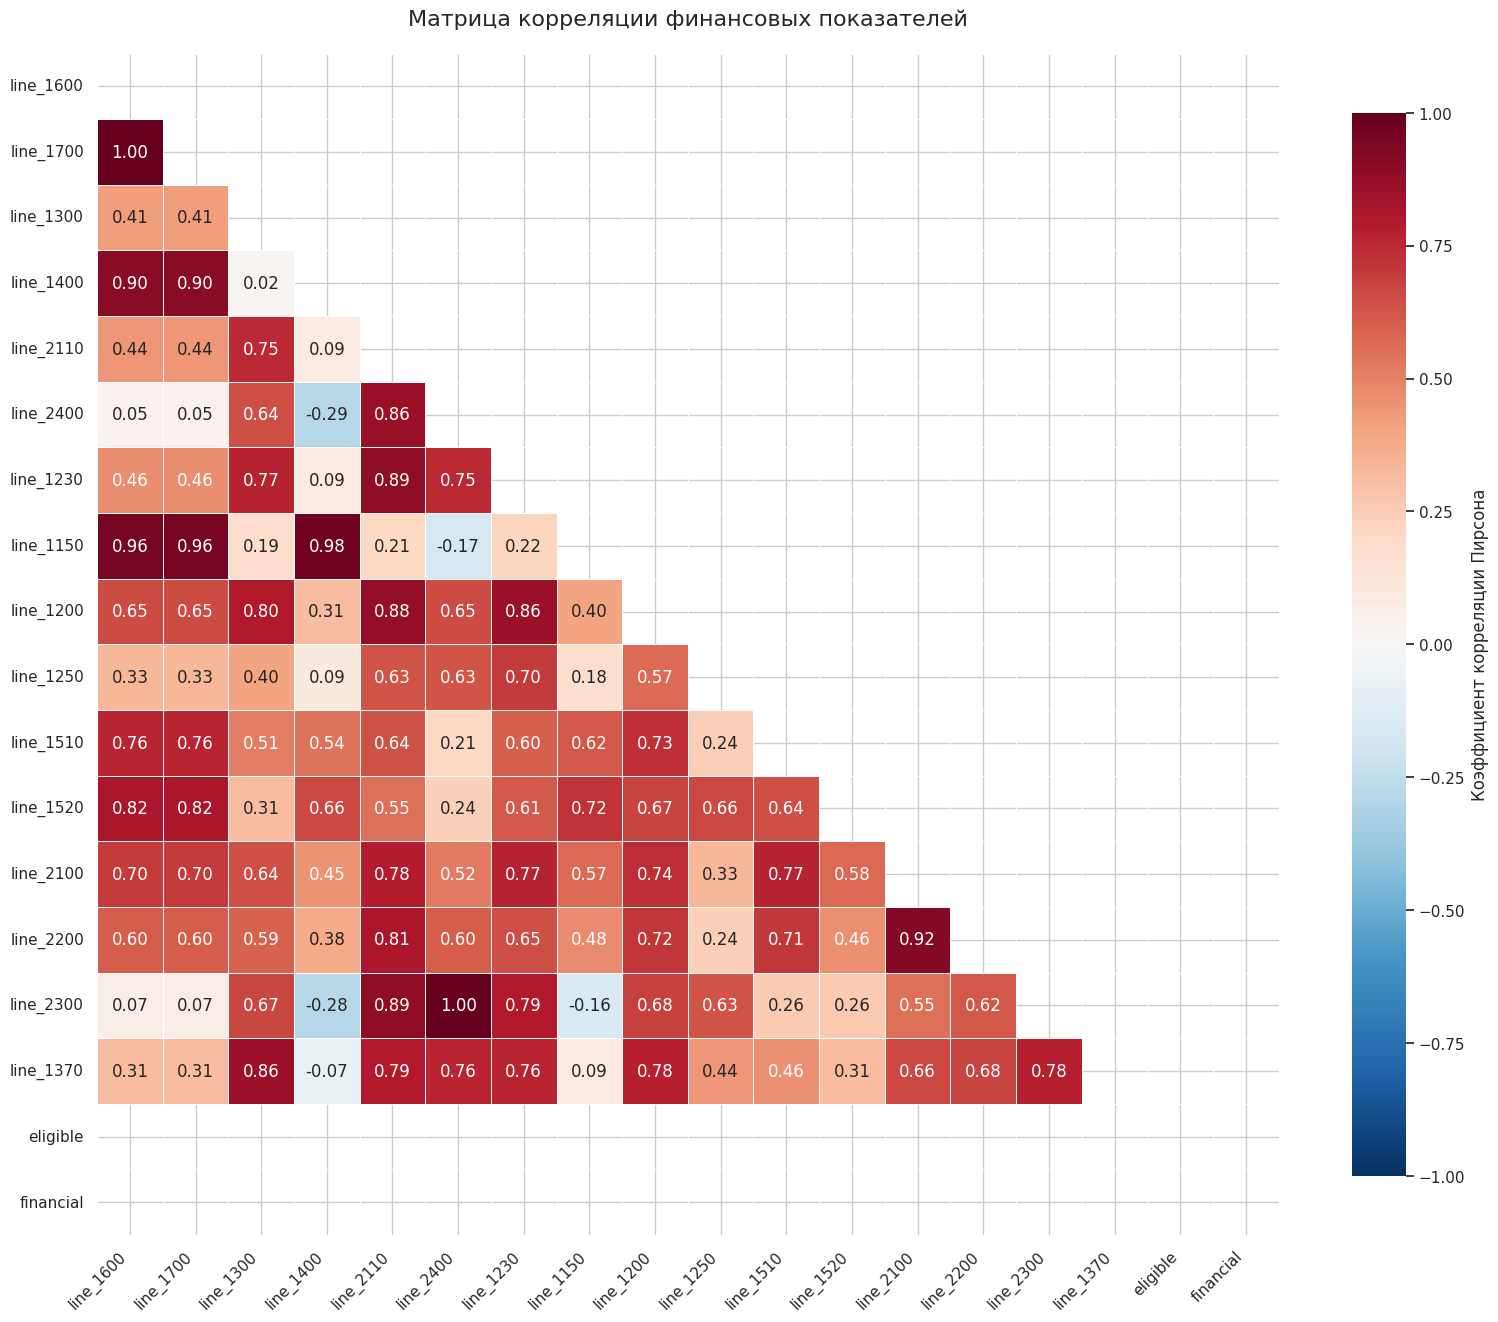


Пары колонок с высокой корреляцией (|r| > 0.7):

line_1600 <-> line_1700
  Корреляция: 1.000 (очень сильная, положительная)

line_2400 <-> line_2300
  Корреляция: 0.996 (очень сильная, положительная)

line_1400 <-> line_1150
  Корреляция: 0.975 (очень сильная, положительная)

line_1600 <-> line_1150
  Корреляция: 0.956 (очень сильная, положительная)

line_1700 <-> line_1150
  Корреляция: 0.956 (очень сильная, положительная)

line_2100 <-> line_2200
  Корреляция: 0.918 (очень сильная, положительная)

line_1600 <-> line_1400
  Корреляция: 0.904 (очень сильная, положительная)

line_1700 <-> line_1400
  Корреляция: 0.904 (очень сильная, положительная)

line_2110 <-> line_1230
  Корреляция: 0.891 (сильная, положительная)

line_2110 <-> line_2300
  Корреляция: 0.889 (сильная, положительная)

line_2110 <-> line_1200
  Корреляция: 0.879 (сильная, положительная)

line_1230 <-> line_1200
  Корреляция: 0.864 (сильная, положительная)

line_2110 <-> line_2400
  Корреляция: 0.861 (сильная, положите

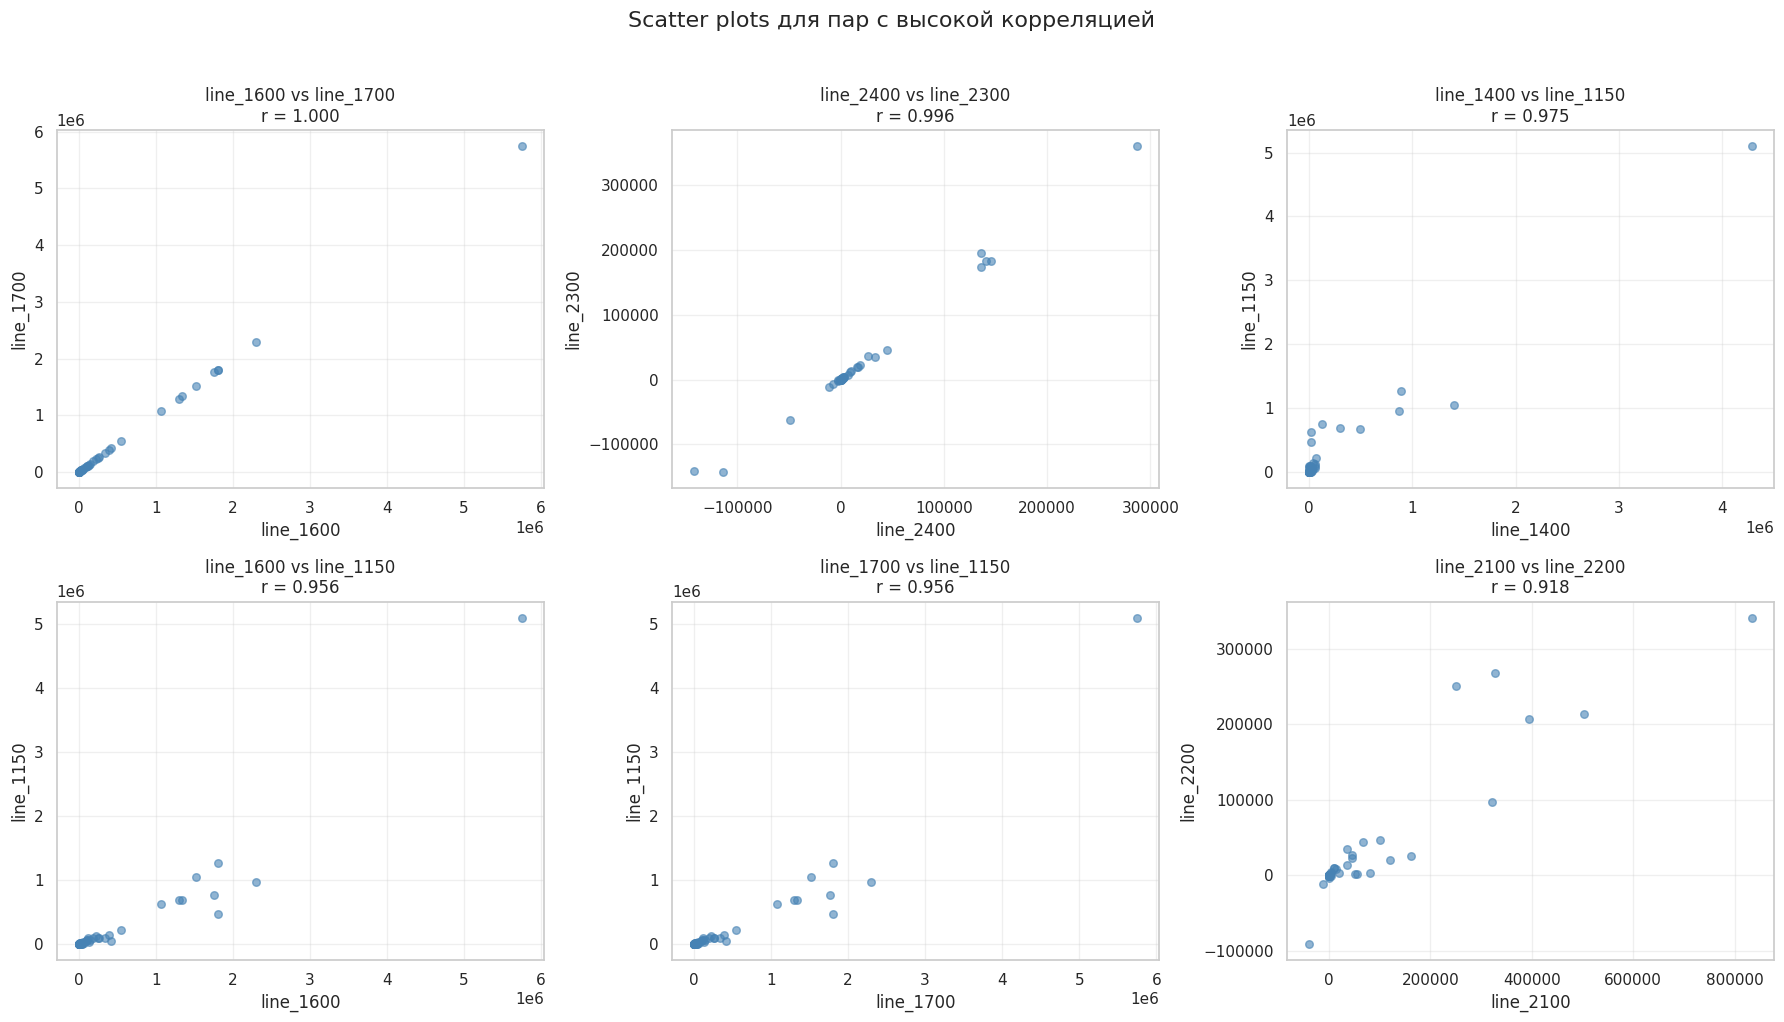


ИТОГОВАЯ СВОДКА:
Всего числовых колонок: 18
Всего возможных пар: 153
Пар с высокой корреляцией (|r| > 0.7): 39
Пар с очень высокой корреляцией (|r| > 0.9): 8


In [12]:
#3
sns.set_theme(style="whitegrid")
# ------------------- 1. Подготовка данных -------------------
# Исключаем идентификаторы из анализа корреляции (они не числовые метрики)
exclude_cols = ["inn", "ogrn"]
numeric_cols = [col for col in RFSD_2023.columns if col not in exclude_cols]

# Оставляем только числовые колонки и убираем строки с пропусками
numeric_df = RFSD_2023.select(numeric_cols).drop_nulls()

print(f"Анализируем {len(numeric_cols)} числовых колонок")
print(f"Осталось строк после удаления пропусков: {len(numeric_df)}")

# ------------------- 2. Вычисление матрицы корреляции -------------------
# Polars вычисляет корреляцию Пирсона
corr_matrix = numeric_df.corr()

print("\n" + "=" * 60)
print("Матрица корреляции (первые 5 строк и столбцов):")
print("=" * 60)
print(corr_matrix.head(5))

# ------------------- 3. Визуализация матрицы корреляции -------------------
fig, ax = plt.subplots(figsize=(16, 14))

# Преобразуем в numpy для heatmap
corr_np = corr_matrix.to_numpy()
labels = numeric_cols

# Маска для верхнего треугольника (чтобы не дублировать информацию)
mask = np.triu(np.ones_like(corr_np, dtype=bool))

# Heatmap
heatmap = sns.heatmap(
    corr_np,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции Пирсона"},
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

plt.title("Матрица корреляции финансовых показателей", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------- 4. Поиск пар с высокой корреляцией -------------------
print("\n" + "=" * 60)
print("Пары колонок с высокой корреляцией (|r| > 0.7):")
print("=" * 60)

# Преобразуем в длинный формат для удобного анализа
high_corr_pairs = []

for i, col1 in enumerate(numeric_cols):
    for j, col2 in enumerate(numeric_cols):
        if i >= j:  # Пропускаем диагональ и дубликаты
            continue

        corr_value = corr_matrix.select(col2)[i, 0]

        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'col1': col1,
                'col2': col2,
                'correlation': corr_value
            })

# Сортируем по абсолютному значению корреляции
high_corr_pairs.sort(key=lambda x: abs(x['correlation']), reverse=True)

for pair in high_corr_pairs:
    strength = "очень сильная" if abs(pair['correlation']) > 0.9 else "сильная"
    direction = "положительная" if pair['correlation'] > 0 else "отрицательная"

    print(f"\n{pair['col1']} <-> {pair['col2']}")
    print(f"  Корреляция: {pair['correlation']:.3f} ({strength}, {direction})")

# ------------------- 5. Визуализация топ-пар -------------------
if len(high_corr_pairs) > 0:
    # Берём топ-6 пар
    top_pairs = high_corr_pairs[:6]

    n_pairs = len(top_pairs)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, pair in enumerate(top_pairs):
        if idx >= len(axes):
            break

        col1, col2 = pair['col1'], pair['col2']
        corr_val = pair['correlation']

        # Scatter plot
        scatter_data = numeric_df.select([col1, col2]).to_numpy()

        axes[idx].scatter(
            scatter_data[:, 0],
            scatter_data[:, 1],
            alpha=0.6,
            s=30,
            color='steelblue'
        )
        axes[idx].set_xlabel(col1)
        axes[idx].set_ylabel(col2)
        axes[idx].set_title(f"{col1} vs {col2}\nr = {corr_val:.3f}")
        axes[idx].grid(True, alpha=0.3)

    # Убираем лишние subplot'ы
    for idx in range(len(top_pairs), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle("Scatter plots для пар с высокой корреляцией", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# ------------------- 6. Итоговая сводка -------------------
print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА:")
print("=" * 60)
print(f"Всего числовых колонок: {len(numeric_cols)}")
print(f"Всего возможных пар: {len(numeric_cols) * (len(numeric_cols) - 1) // 2}")
print(f"Пар с высокой корреляцией (|r| > 0.7): {len(high_corr_pairs)}")
print(f"Пар с очень высокой корреляцией (|r| > 0.9): {sum(1 for p in high_corr_pairs if abs(p['correlation']) > 0.9)}")

#3
1. line_1600 ↔ line_1700 (Корр. = 1.000)
Стопроцентная связь. Если активы растут, пассивы растут ровно на ту же величину и наоборот.
Причина:
Это не корреляция в статистическом смысле, а специфика бухгалтерского учета. В датасете эти два поля просто дублируют друг друга.

2. line_2400 ↔ line_2300 (Корр. = 0.996)
Почти идеальная связь. Чистая прибыль практически полностью повторяет динамику прибыли до налогообложения.
Причина:
Так как расчет параметра line_2300 осуществляется на основе параметра line_2400 с применением налогового коэффициента.

3. line_1400 ↔ line_1150 (Корр. = 0.975)
Компании с большими основными средствами имеют большие долгосрочные обязательства, и наоборот.

Причина:
Крупные капитальные вложения в основные средства финансируются за счет кредитов и займов с большими сроками.

4–5. line_1600 ↔ line_1150 и line_1700 ↔ line_1150 (Корр. = 0.956)
Размер компании (активы) почти полностью определяется стоимостью ее основных средств.

Причина:
Специфика бизнеса компаний представленных в датасете. Компаниям для бизнеса требуется много оборудования и других активов.

6. line_2100 ↔ line_2200 (Корр. = 0.918)
Валовая прибыль и прибыль от продаж движутся почти синхронно.

Причина:
Если коммерческие и управленческие расходы в среднем составляют примерно фиксированный процент от валовой прибыли (или меняются медленно), то line_2200 будет почти линейно зависеть от line_2100.
Это говорит о том, что в выборке расходы на продажу и управление пропорциональны объему бизнеса, а не являются фиксированными затратами.

7–8. line_1600 ↔ line_1400 и line_1700 ↔ line_1400 (Корр. = 0.904)
Чем крупнее компания, тем больше у нее долгосрочных долгов.

Причина:
Крупные компании с большими основными средствами имеют большие долгосрочные обязательства, и наоборот.

✅ Будет построено графиков: 8 из 8


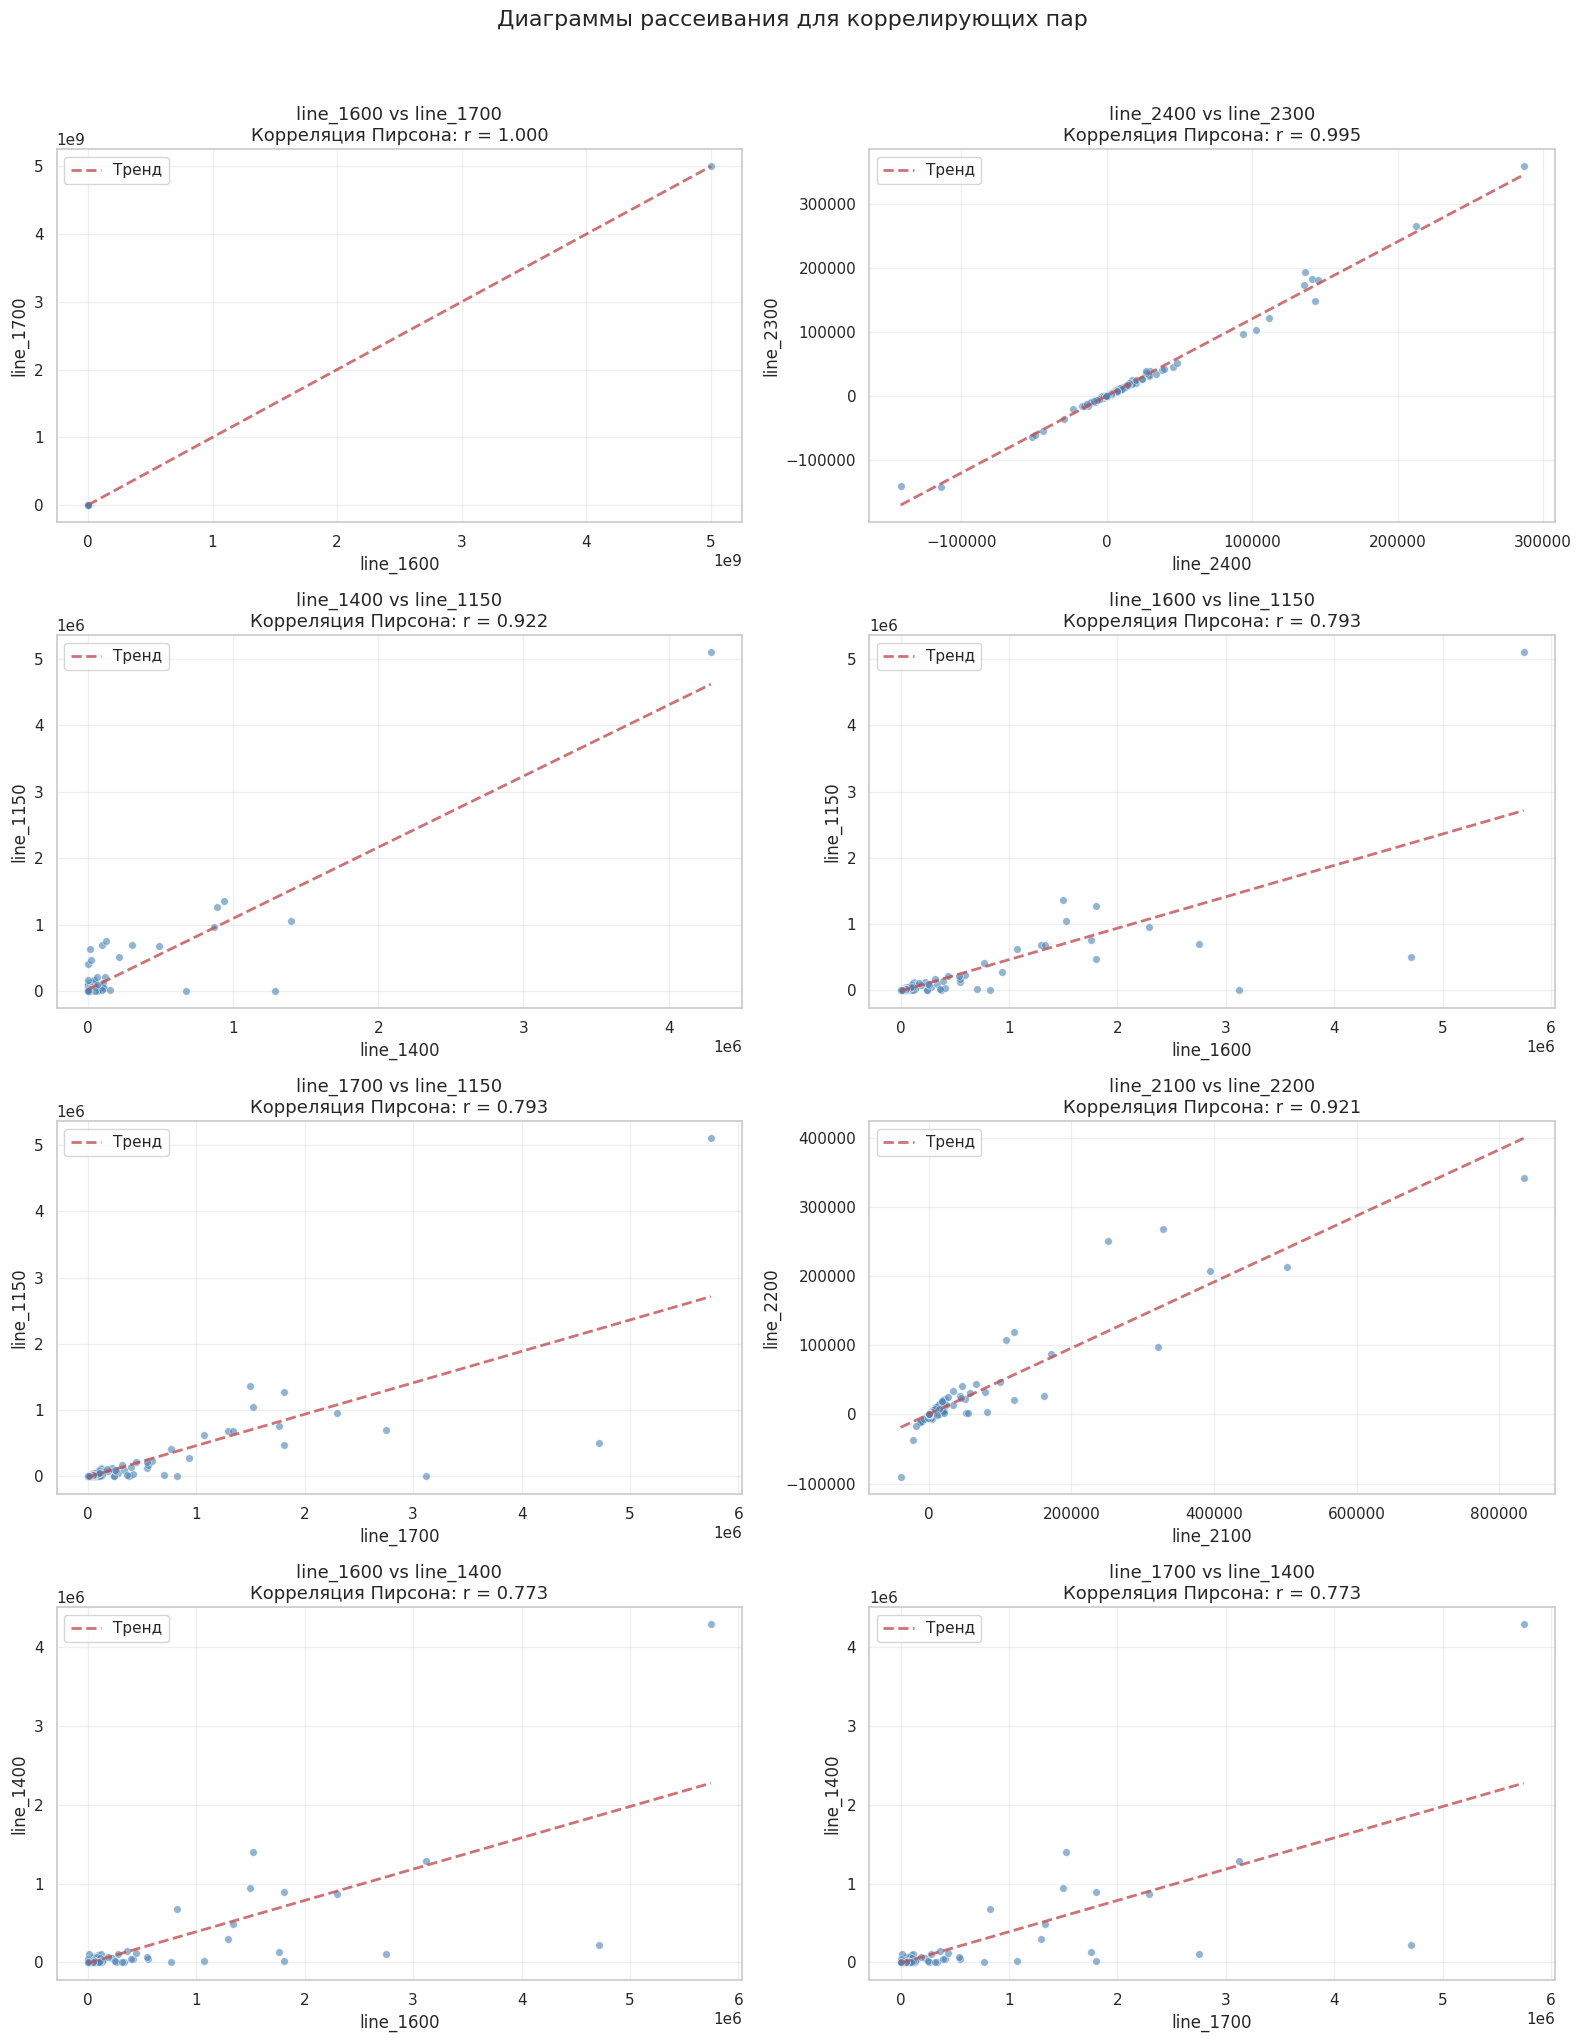

In [9]:
#4
# Устанавливаем стиль
sns.set_theme(style="whitegrid")

# Пары колонок для анализа
pairs = [
    ('line_1600', 'line_1700'),
    ('line_2400', 'line_2300'),
    ('line_1400', 'line_1150'),
    ('line_1600', 'line_1150'),
    ('line_1700', 'line_1150'),
    ('line_2100', 'line_2200'),
    ('line_1600', 'line_1400'),
    ('line_1700', 'line_1400'),
]

# Проверяем, какие колонки реально есть в DataFrame
available_cols = set(RFSD_2023.columns)
valid_pairs = []

for col1, col2 in pairs:
    if col1 in available_cols and col2 in available_cols:
        valid_pairs.append((col1, col2))
    else:
        missing = []
        if col1 not in available_cols:
            missing.append(col1)
        if col2 not in available_cols:
            missing.append(col2)
        print(f"⚠️ Пропускаем пару ({col1}, {col2}): отсутствуют колонки {missing}")

if not valid_pairs:
    print("❌ Нет доступных пар для построения графиков!")
else:
    print(f"✅ Будет построено графиков: {len(valid_pairs)} из {len(pairs)}")

    # Определяем размер сетки
    n_pairs = len(valid_pairs)
    n_cols = 2
    n_rows = (n_pairs + n_cols - 1) // n_cols  # округление вверх

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

    # Если всего 1 пара, axes не будет массивом
    if n_pairs == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, (col1, col2) in enumerate(valid_pairs):
        ax = axes[idx]

        # Получаем данные и убираем строки с пропусками
        pair_df = RFSD_2023.select([col1, col2]).drop_nulls()

        if len(pair_df) == 0:
            ax.text(0.5, 0.5, "Нет данных", ha='center', va='center', fontsize=14)
            ax.set_title(f"{col1} vs {col2}")
            continue

        x = pair_df[col1].to_numpy()
        y = pair_df[col2].to_numpy()

        # Считаем корреляцию Пирсона
        corr_coef = np.corrcoef(x, y)[0, 1]

        # Scatter plot
        ax.scatter(x, y, alpha=0.6, s=30, color='steelblue', edgecolors='white', linewidth=0.5)

        # Линия тренда (линейная регрессия)
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, label=f"Тренд")

        # Оформление
        ax.set_xlabel(col1, fontsize=12)
        ax.set_ylabel(col2, fontsize=12)
        ax.set_title(f"{col1} vs {col2}\nКорреляция Пирсона: r = {corr_coef:.3f}", fontsize=13)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    # Убираем пустые subplot'ы
    for idx in range(len(valid_pairs), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle("Диаграммы рассеивания для коррелирующих пар", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


#5
1. Вывод по данным датасета:
Датасет представляет собой выборку российских малых и микропредприятий с сильным перекосом вправо. Подавляющее большинство компаний — это очень маленькие фирмы, но несколько крупных компаний представленных в данных искажают средние значения. Любой агрегированный анализ (средние, регрессии) будет неустойчивым — нужно анализировать такие типы компаний по отдельности.
Медиана активов = 318 тыс. руб.
Среднее значение = 6.4 млн руб. - в 20 раз выше медианы
Максимальное значение = 5 млрд руб.
75% компаний имеют активы до 6.3 млн руб., но есть единичные крупные компании.

Также стоит отметить низкое качество данных, очень много пропусков, что значительно влияют на результаты анализа данных.

2. Вывод по специфике компаний из датасета:
- Сильнейшая корреляция активов (line_1600) с основными средствами (line_1150) — r = 0.956
- Активы сильно коррелируют с кредиторской задолженностью (line_1520) — r = 0.816
- Основные средства коррелируют с долгосрочными обязательствами (line_1400) — r = 0.975

Баланс компании в выборке в основном состоит из:
- Основных средств (здания, оборудование), которые составляют большую долю активов.
- Кредиторской задолженности перед поставщиками — основного источника финансирования.
- Долгосрочных кредитов, которые берутся под покупку основных средств.

Это характерно для бизнесов, которые требуют большой материальной базы, а оборотный капитал финансируется за счет отсрочек платежей, поэтому это скорее всего производственные компании.

3. Вывод по корреляции данных:
- line_1600 ↔ line_1700: r = 1.000 (абсолютная корреляция)
- line_2400 ↔ line_2300: r = 0.996 (чистая прибыль = прибыль до налога + х% налога)
- line_2100 ↔ line_2200: r = 0.918 (валовая прибыль и прибыль от продаж)

Неокторые корреляции в данных не должны вести к содержательным выводам, они возникают из-за правил бухгалтерского учета и налогового законодательства. Такие корреляции могут влиять на качество анализа их нужно учитывать и обрабатывать иначе.